# 02 — ARIMAX Model Search

## Purpose
Combinatorial ARIMAX (SARIMAX with exogenous regressors) grid search for all 5
behavioral targets, using `run_arima` from the core library
(`src/irrbb_behavioral_model.py`), restricted to each target's candidate
predictor shortlist from `01_feature_screening.ipynb`.

This implements the search strategy described in `docs/methodology.md` §1.4:
enumerate macro-variable subsets × `(p,d,q)` orders, select the best `(p,d,q)`
per subset by **out-of-sample MAPE**, and rank all subsets into a leaderboard.
Final model *selection* (diagnostics, significance filtering) is deferred to
`03_diagnostics_selection.ipynb` — this notebook only produces the ranked
candidate pool.

## Compute-budget note
To keep runtime practical, each target's search is restricted to its **top-5
macro predictors** (by lag-optimal correlation from notebook 01) combined in
subsets of size `x_num ∈ {1, 2}`, with the anomaly dummy `XAO` always appended
(`dummy_variable=True`) rather than combined into the `x_num` count. This was
empirically timed at ≈2 sec/combination with the full default `(p,d,q) ∈
{0,1,2}³` order grid — see the timing check below.


In [1]:
import sys, json, time, pickle, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import irrbb_behavioral_model as m

plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/raw/synthetic_irrbb_data.csv", parse_dates=["Date"])
with open("../data/processed/feature_shortlist.json") as f:
    shortlist = json.load(f)

TARGETS = ["TDER_IDR", "TDER_USD", "PL_PREPAY", "MTG_PREPAY", "JF_PREPAY"]
TEST_SIZE = 12
TOP_K = 5

# Candidate pool per target: top-K macro predictors (XAO handled separately
# via dummy_variable=True, so excluded from the combinatorial x_num count).
candidate_pool = {
    t: [c for c in shortlist[t] if c != "XAO"][:TOP_K] for t in TARGETS
}
for t in TARGETS:
    print(f"{t:12s} -> {candidate_pool[t]}")


TDER_IDR     -> ['X_GDP_YOY', 'X_SUN10Y']
TDER_USD     -> ['X_FEDFUNDS', 'X_BI7DRR', 'X_IHSG', 'X_USDIDR']
PL_PREPAY    -> ['X_SUN10Y', 'X_BRENT', 'X_COAL', 'X_CPI_YOY', 'X_GDP_YOY']
MTG_PREPAY   -> ['X_SUN10Y', 'X_GDP_YOY', 'X_BI7DRR', 'X_BRENT', 'X_COAL']
JF_PREPAY    -> ['X_CCI', 'X_GDP_YOY', 'X_IHSG', 'X_BI7DRR', 'X_FEDFUNDS']


## 1. Combinatorial Search per Target

For each target, `run_arima` is called twice — once with `x_num=1` (single
macro predictor + XAO) and once with `x_num=2` (pairs of macro predictors +
XAO) — and the resulting leaderboards are concatenated. Fitted model objects
are kept in a nested dict `fitted_models[target][x_label]` for use in
`03_diagnostics_selection.ipynb`.


In [2]:
all_results = {}
fitted_models = {}

t0_total = time.time()
for target in TARGETS:
    pool = candidate_pool[target]
    t0 = time.time()

    frames = []
    models_this_target = {}

    for x_num in (1, 2):
        if len(pool) < x_num:
            continue
        res_df, models_dict = m.run_arima(
            df, y_col=target, x_num=x_num, x_list=pool,
            test_size=TEST_SIZE, min_obs=36, dummy_variable=True,
            verbose=False, y_transform="logit",
        )
        frames.append(res_df)
        models_this_target.update(models_dict)

    combined = pd.concat(frames, ignore_index=True).sort_values(
        "MAPE Test", na_position="last"
    ).reset_index(drop=True)

    all_results[target] = combined
    fitted_models[target] = models_this_target

    dt = time.time() - t0
    best_mape = combined["MAPE Test"].min()
    print(f"{target:12s} | {len(combined):3d} combinations | {dt:5.1f}s "
          f"| best MAPE = {best_mape:.2f}%")

print(f"\nTotal search time: {time.time() - t0_total:.1f}s")


TDER_IDR     |   3 combinations |   5.3s | best MAPE = 10.28%


TDER_USD     |  10 combinations |  25.0s | best MAPE = 16.79%


PL_PREPAY    |  15 combinations |  28.1s | best MAPE = 14.35%


MTG_PREPAY   |  15 combinations |  29.6s | best MAPE = 11.64%


JF_PREPAY    |  15 combinations |  32.0s | best MAPE = 15.92%

Total search time: 120.1s


## 2. Leaderboard — Top 5 Candidates per Target


In [3]:
for target in TARGETS:
    print(f"=== {target} ===")
    display_cols = ["X Set", "Order", "AIC Train", "MAPE Test", "N Train", "N Test"]
    print(all_results[target][display_cols].head(5).to_string(index=False))
    print()


=== TDER_IDR ===
                     X Set     Order  AIC Train  MAPE Test  N Train  N Test
X_GDP_YOY + X_SUN10Y + XAO (1, 1, 2)  -1.187163  10.281343       60      12
           X_GDP_YOY + XAO (2, 1, 1)  -5.138430  10.446492       60      12
            X_SUN10Y + XAO (2, 1, 2)  -6.239486  10.622539       60      12

=== TDER_USD ===
                      X Set     Order  AIC Train  MAPE Test  N Train  N Test
X_FEDFUNDS + X_USDIDR + XAO (2, 2, 1)  31.102838  16.785194       60      12
               X_IHSG + XAO (1, 1, 0)  28.169570  17.342655       60      12
             X_BI7DRR + XAO (1, 1, 0)  26.216591  17.377982       60      12
    X_BI7DRR + X_IHSG + XAO (1, 1, 0)  28.154034  17.568612       60      12
           X_FEDFUNDS + XAO (1, 2, 1)  27.692126  17.698470       60      12

=== PL_PREPAY ===
                      X Set     Order  AIC Train  MAPE Test  N Train  N Test
X_CPI_YOY + X_GDP_YOY + XAO (0, 2, 1)  19.703219  14.351210       60      12
              X_BRENT + XA

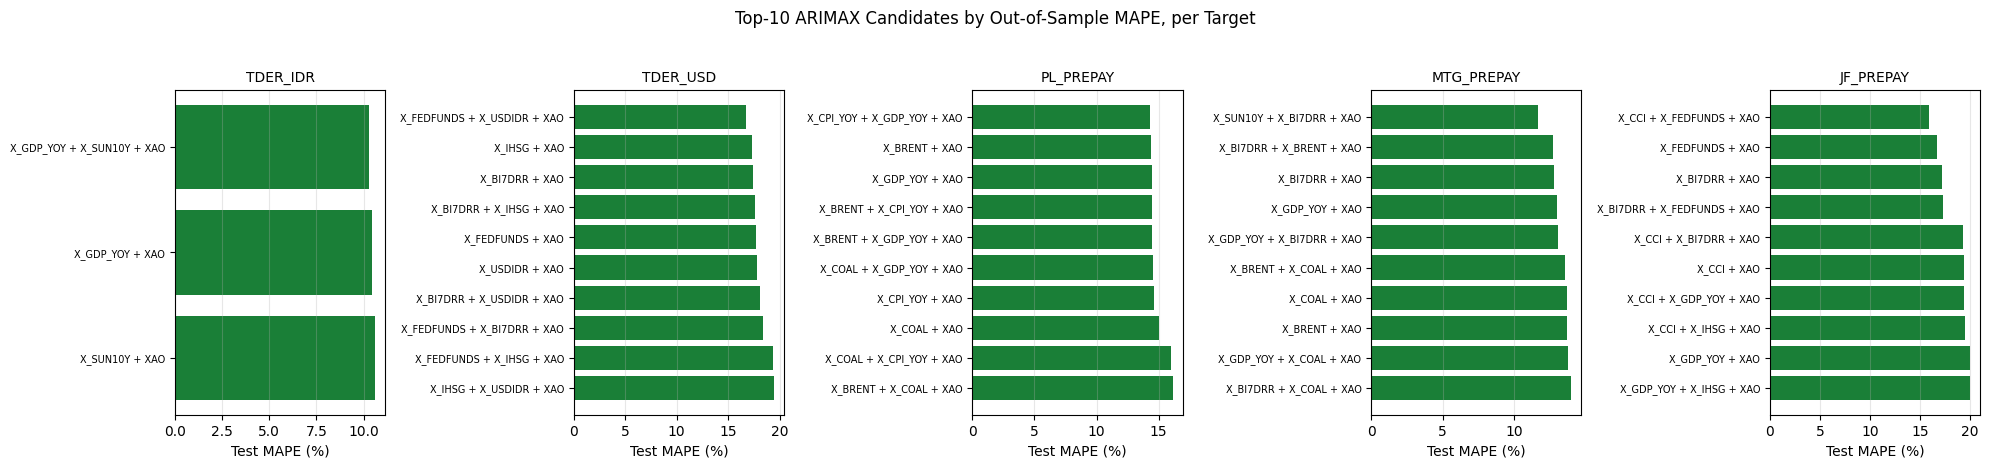

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4.5), sharey=False)
for ax, target in zip(axes, TARGETS):
    top10 = all_results[target].dropna(subset=["MAPE Test"]).head(10)
    ax.barh(range(len(top10)), top10["MAPE Test"], color="#1a7f37")
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(top10["X Set"], fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel("Test MAPE (%)")
    ax.set_title(target, fontsize=10)
    ax.grid(alpha=0.3, axis="x")
fig.suptitle("Top-10 ARIMAX Candidates by Out-of-Sample MAPE, per Target", y=1.03)
plt.tight_layout()
plt.show()


**Observation:** the best-fitting predictor combination differs meaningfully
across targets — consistent with the distinct behavioral driver design used
in `00_data_generation.ipynb` (e.g. `TDER_USD` favoring `X_FEDFUNDS`,
`JF_PREPAY` favoring `X_CCI`/`X_GDP_YOY`). This is a useful sanity check that
the search process is recovering economically sensible structure rather than
pure noise-fitting — though final confirmation requires the residual
diagnostics and coefficient-significance checks in the next notebook (a low
MAPE alone does not certify a *valid* model — see Methodology §1.4 and §4).


## 3. Illustrative Deep-Dive — Best Model for One Target

As a preview (full diagnostics for *all* shortlisted candidates are run in
`03_diagnostics_selection.ipynb`), the SARIMAX summary of the single
best-MAPE model for `MTG_PREPAY` is inspected here.


In [5]:
best_key_mtg = all_results["MTG_PREPAY"].iloc[0]["X Set"]
best_model_mtg = fitted_models["MTG_PREPAY"][best_key_mtg]
print(f"Best candidate: {best_key_mtg}\n")
print(best_model_mtg.summary())


Best candidate: X_SUN10Y + X_BI7DRR + XAO

                               SARIMAX Results                                
Dep. Variable:             MTG_PREPAY   No. Observations:                   60
Model:               SARIMAX(0, 0, 1)   Log Likelihood                  11.731
Date:                Sat, 22 Aug 2026   AIC                            -11.463
Time:                        03:35:56   BIC                              0.900
Sample:                             0   HQIC                            -6.647
                                 - 60                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -3.3510      0.046    -73.250      0.000      -3.441      -3.261
X_SUN10Y      -0.2118      0.048     -4.409      0.000      -0.306      -0.118
X_BI7DRR 

## 4. Save Leaderboards & Fitted Models

Results are persisted to `outputs/model_leaderboard/` for use in
`03_diagnostics_selection.ipynb`:
- `{target}_leaderboard.csv` — per-target ranked results table.
- `fitted_models.pkl` — nested dict of fitted `SARIMAXResults` objects
  (`fitted_models[target][x_label]`).


In [6]:
import os
os.makedirs("../outputs/model_leaderboard", exist_ok=True)

for target in TARGETS:
    all_results[target].to_csv(f"../outputs/model_leaderboard/{target}_leaderboard.csv", index=False)

with open("../outputs/model_leaderboard/fitted_models.pkl", "wb") as f:
    pickle.dump(fitted_models, f)

print("Saved:")
for target in TARGETS:
    print(f"  ../outputs/model_leaderboard/{target}_leaderboard.csv")
print("  ../outputs/model_leaderboard/fitted_models.pkl")


Saved:
  ../outputs/model_leaderboard/TDER_IDR_leaderboard.csv
  ../outputs/model_leaderboard/TDER_USD_leaderboard.csv
  ../outputs/model_leaderboard/PL_PREPAY_leaderboard.csv
  ../outputs/model_leaderboard/MTG_PREPAY_leaderboard.csv
  ../outputs/model_leaderboard/JF_PREPAY_leaderboard.csv
  ../outputs/model_leaderboard/fitted_models.pkl


## Next Step
Proceed to **`03_diagnostics_selection.ipynb`** — run the full diagnostic
battery (`evaluate_selected_models`: Ljung-Box, Heteroskedasticity,
Jarque-Bera, coefficient significance) across each target's shortlisted
ARIMAX candidates, and select the final model per target based on combined
accuracy + diagnostic validity, per `docs/methodology.md` §4.
